In [80]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [81]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Ti


In [82]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
])

In [83]:
train_dataset = datasets.ImageFolder(
    "../data2/train_aug",
    transform=transform
)

val_dataset = datasets.ImageFolder(
    "../data2/val",
    transform=transform
)

In [84]:
print(train_dataset.classes)

['Bacteria', 'Fungi', 'Healthy', 'Nematode', 'Pest', 'Phytopthora', 'Virus']


In [85]:
from collections import Counter

print(Counter(train_dataset.targets))
print(Counter(val_dataset.targets))

Counter({1: 3588, 4: 2928, 0: 2730, 6: 2550, 5: 1662, 2: 960, 3: 324})
Counter({1: 150, 4: 123, 0: 114, 6: 107, 5: 70, 2: 41, 3: 14})


In [86]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

In [87]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [88]:
model = models.resnet50(pretrained=True)

c:\Users\desig\Desktop\Summer research\CV\Potatoplant\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\desig\Desktop\Summer research\CV\Potatoplant\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [89]:
model.fc = nn.Linear(model.fc.in_features, 7)

In [90]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [91]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cuda


In [92]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.fc.parameters(),
    lr=1e-4
)

In [93]:
from torchsummary import summary

summary(model, input_size=(3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [94]:
model.train()

running_loss = 0.0

for images, labels in train_loader:

    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    outputs = model(images)

    loss = criterion(outputs, labels)

    loss.backward()

    optimizer.step()

    running_loss += loss.item()

print("Training completed!")
print("Loss:", running_loss)

Training completed!
Loss: 673.3898054361343


In [95]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total

print(f"Validation Accuracy: {accuracy:.2f}%")

Validation Accuracy: 58.48%


In [96]:
train_losses = []
val_accuracies = []

In [97]:
num_epochs = 30

for epoch in range(num_epochs):

    # TRAINING
    model.train()

    running_loss = 0.0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)

    train_losses.append(epoch_loss)

    # VALIDATION
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    val_accuracies.append(accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {epoch_loss:.4f}")
    print(f"Validation Accuracy: {accuracy:.2f}%")

Epoch 1/30
Loss: 1.1165
Validation Accuracy: 65.11%
Epoch 2/30
Loss: 0.9900
Validation Accuracy: 66.72%
Epoch 3/30
Loss: 0.9178
Validation Accuracy: 68.82%
Epoch 4/30
Loss: 0.8692
Validation Accuracy: 67.37%
Epoch 5/30
Loss: 0.8393
Validation Accuracy: 68.66%
Epoch 6/30
Loss: 0.8148
Validation Accuracy: 70.11%
Epoch 7/30
Loss: 0.7943
Validation Accuracy: 70.76%
Epoch 8/30
Loss: 0.7789
Validation Accuracy: 68.17%
Epoch 9/30
Loss: 0.7658
Validation Accuracy: 70.92%
Epoch 10/30
Loss: 0.7483
Validation Accuracy: 71.24%
Epoch 11/30
Loss: 0.7384
Validation Accuracy: 70.60%
Epoch 12/30
Loss: 0.7242
Validation Accuracy: 68.82%
Epoch 13/30
Loss: 0.7217
Validation Accuracy: 71.24%
Epoch 14/30
Loss: 0.7097
Validation Accuracy: 69.79%
Epoch 15/30
Loss: 0.7021
Validation Accuracy: 70.11%
Epoch 16/30
Loss: 0.6941
Validation Accuracy: 69.63%
Epoch 17/30
Loss: 0.6887
Validation Accuracy: 69.95%
Epoch 18/30
Loss: 0.6789
Validation Accuracy: 69.14%
Epoch 19/30
Loss: 0.6795
Validation Accuracy: 70.11%
Ep

In [98]:
torch.save(model.state_dict(), "../models/resnet50_data2.pth")

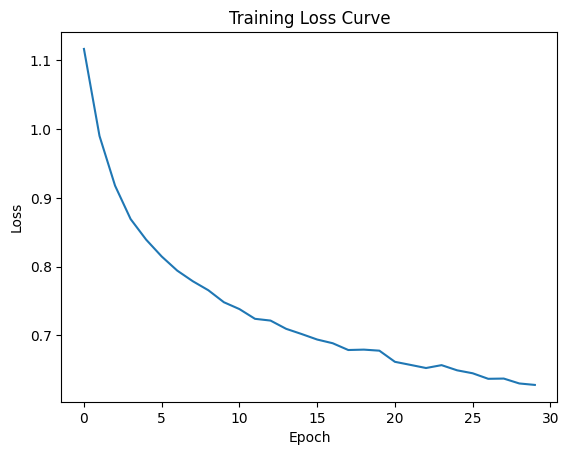

In [99]:
import matplotlib.pyplot as plt

plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.show()

In [100]:
plt.savefig("../results/resnet_loss_data2.png")

<Figure size 640x480 with 0 Axes>

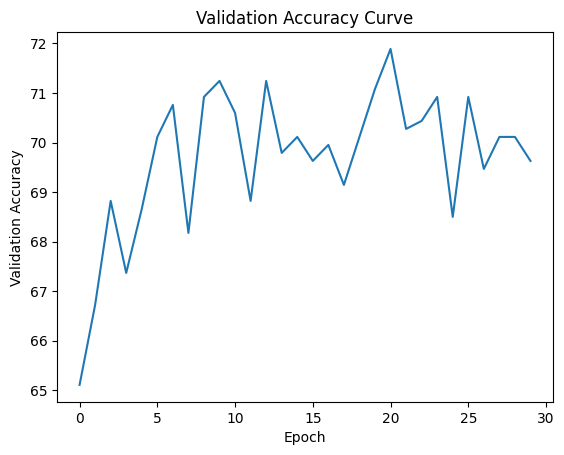

In [101]:
plt.plot(val_accuracies)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")

plt.title("Validation Accuracy Curve")

plt.show()

In [102]:
plt.savefig("../results/resnet_acc_data2.png")

<Figure size 640x480 with 0 Axes>